In [1]:
#==================================================
'''
## 3. CNN이미지 분류 실습
- 예제 데이터 : Fashion MNIST
- CNN 기반 이미지 분류 
- 학습결과 저장 
- 저장된 모델/스케일러/학습 이력 불러오기
- 신규 데이터 예측
- 학습결과 및 예측결과 시각화
'''
#==================================================

'\n## 3. 다중 클래스 분류(Multi-class Classification) 실습\n- 10개 클래스 분류\n- 학습 결과 저장\n- 저장된 모델/스케일러/학습 이력 불러오기\n- 신규 데이터 예측\n- 학습결과 및 예측결과 시각화\n'

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
import joblib                                        # 파이썬 객체 저장을 위한 joblib

import tensorflow as tf                              # 딥러닝 프레임 워크 

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

In [27]:
# ============================================
# 1. 데이터 가져오기
# ============================================

# fashion mnist 데이터 가져오기
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# 클래스 이름 정의
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# 데이터 shape 확인
print('X_train shape: ', X_train.shape)    
print('X_test shape: ', X_test.shape)

X_train shape:  (60000, 28, 28)
X_test shape:  (10000, 28, 28)


In [28]:
# ============================================
# 2. 데이터 정규화
# ============================================

# 픽셀값 0~1 범위로 정규화
X_train = X_train / 255.0
X_test = X_test / 255.0

# CNN 입력 형태에 맞게 채널 차원을 Reshape <-- Conv2D 는 입력수가 4개 (이미지수 , 높이 , 너비 , 채널 수 ) 
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [56]:
# ============================================
# 3. 모델 정의 (CNN)
# ============================================

model = Sequential()    # 순차형 신경망 생성

# 첫 번째 합성곱 층 추가
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
# 풀링 층 추가
model.add(MaxPooling2D((2,2)))
# Dropout 적용
model.add(Dropout(0.20))

# 두 번째 합성곱 층 추가
model.add(Conv2D(64, (3,3), activation='relu'))
# 풀링 층 추가
model.add(MaxPooling2D((2,2)))
# Dropout 적용
model.add(Dropout(0.20))

# 1차원 벡터로 펼침
model.add(Flatten())
# 완전 연결층 추가
model.add(Dense(128, activation='relu'))
# 드롭아웃 20% 적용
model.add(Dropout(0.2))

# 출력층 추가
model.add(Dense(10, activation='softmax'))

In [57]:
# ============================================
# 4. 모델 컴파일 설정 
# ============================================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 학습 종료 설정 
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
#========================================
# 5. 모델 학습 
#========================================
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    #callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8376 - loss: 0.4479 - val_accuracy: 0.8618 - val_loss: 0.3895
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8702 - loss: 0.3630 - val_accuracy: 0.8816 - val_loss: 0.3215
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8808 - loss: 0.3231 - val_accuracy: 0.8932 - val_loss: 0.2975
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8933 - loss: 0.2950 - val_accuracy: 0.8987 - val_loss: 0.2775
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8976 - loss: 0.2776 - val_accuracy: 0.9020 - val_loss: 0.2661
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9032 - loss: 0.2627 - val_accuracy: 0.9039 - val_loss: 0.2591
Epoch 7/30
480/750 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9056 - loss: 0.2535

In [32]:
# ============================================
# 6. 성능 평가
# ============================================

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

# 결과 출력
print("테스트 손실: ", test_loss)
print("테스트 정확도: ", test_acc)

테스트 손실:  0.3459429144859314
테스트 정확도:  0.9021000266075134


In [33]:
# ============================================
# 7. 예측확률 계산 
# ============================================
# 테스트 데이터 예측 확률 계산 
y_prob = model.predict(X_test)

# 최종 예측 클래스 계산 
y_pred= np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [42]:
# ============================================
# 8. 학습 결과 저장
# ============================================

# 모델 저장
model.save("./model/cnn_fashion_mnist.h5")

# 모델 학습 결과 읽어오기
loaded_model = tf.keras.models.load_model("./model/cnn_fashion_mnist.h5")

In [43]:
# ============================================
# 9. 신규 데이터 예측/분류
# ============================================

# 학습하지 않은 테스트 이미지 5개 읽어오기
new_images = X_test[:5]

# 신규 이미지 예측
new_prob = loaded_model.predict(new_images)

# 최종 클래스 예측값 계산
new_pred = np.argmax(new_prob, axis=1)

# 예측결과 출력
for i in range(len(new_images)):
    print(f"{i+1}번 이미지 - 예측클래스: {new_pred[i]} ({class_names[new_pred[i]]})")

print("\n실제값: ", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1번 이미지 - 예측클래스: 9 (Ankle boot)
2번 이미지 - 예측클래스: 2 (Pullover)
3번 이미지 - 예측클래스: 1 (Trouser)
4번 이미지 - 예측클래스: 1 (Trouser)
5번 이미지 - 예측클래스: 6 (Shirt)

실제값:  [9 2 1 1 6]


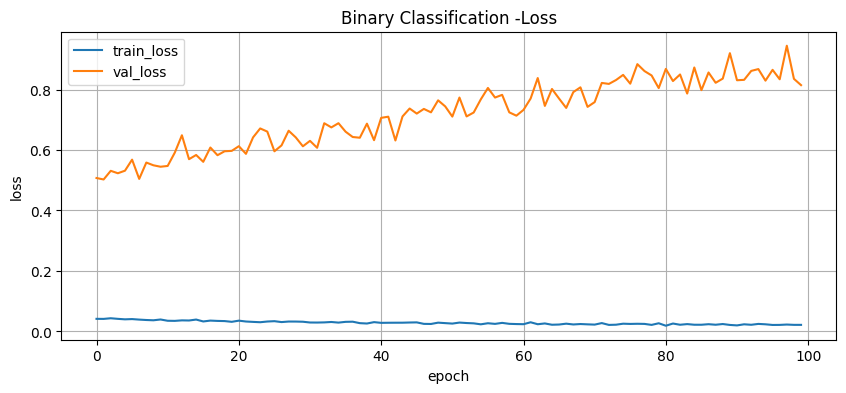

In [54]:
# ============================================
# 11. 시각화 결과 확인
# ============================================

# 학습, loss 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Binary Classification -Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True) # 그래프 격자 표시 
plt.show()

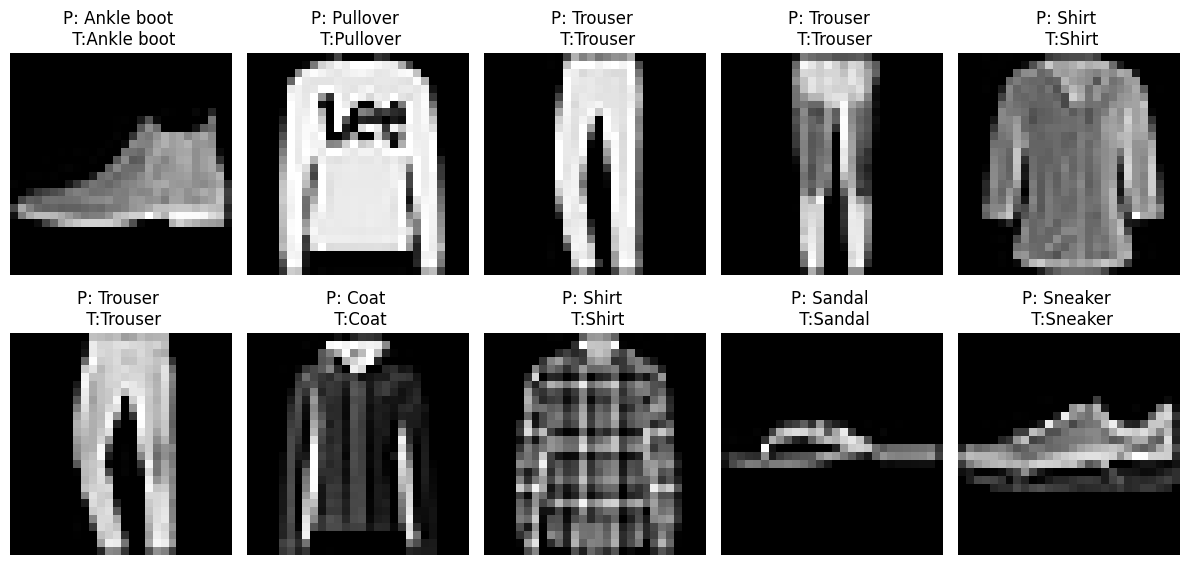

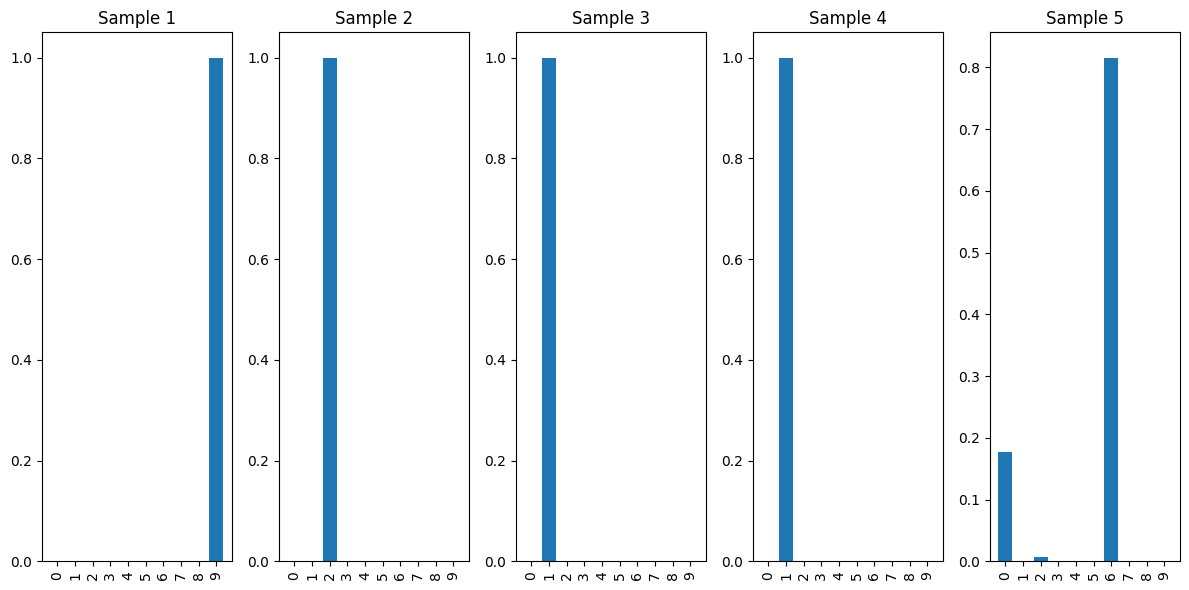

In [55]:
# 테스트 이미지(10개)와 예측 결과 시각화
plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"P: {class_names[y_pred[i]]} \n T:{class_names[y_test[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 신규 이미지 5개에 대한 확률 분포 시각화
plt.figure(figsize=(12,6))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.bar(range(10), new_prob[i])
    plt.title(f"Sample {i+1}")
    plt.xticks(range(10), rotation=90)

plt.tight_layout()
plt.show()